In [1]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [2]:
os.getuid()

1000

In [3]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
# regelum_data/outputs/2024-11-07/11-31-51

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=True
                                )

df.head()

Load path: /home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-07/11-31-51


,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,Linear Velocity [m/s],Angular Velocity [rad/s],...,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path
0,0.000,-1.00,None,-1.00,1,1,red_cube,0,0.475357,0.728461,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
0,0.000,-1.00,None,-1.00,1,2,red_cube,1,0.078009,-1.080177,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
0,0.000,0.40,None,0.40,1,3,red_cube,2,0.433088,0.317501,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
1,0.000,0.75,None,1.15,1,3,red_cube,3,0.354036,-1.505365,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
2,0.165,0.64,None,1.79,1,3,red_cube,4,0.484955,1.043870,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...


In [4]:
df.task_name

0    red_cube
0    red_cube
0    red_cube
1    red_cube
2    red_cube
       ...   
0    red_cube
0    red_cube
0    red_cube
0    red_cube
0    red_cube
Name: task_name, Length: 535, dtype: object

In [5]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer

tmp = df.apply(extract_columns, axis=1, result_type='expand')
tmp.columns = ["category", "controller", "is_reset_buffer"]
df = pd.concat([df, tmp], axis=1)

In [6]:
df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,Linear Velocity [m/s],Angular Velocity [rad/s],...,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,category,controller,is_reset_buffer
0,0.000,-1.00,None,-1.00,1,1,red_cube,0,0.475357,0.728461,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,SAC,False
0,0.000,-1.00,None,-1.00,1,2,red_cube,1,0.078009,-1.080177,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,SAC,False
0,0.000,0.40,None,0.40,1,3,red_cube,2,0.433088,0.317501,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,SAC,False
1,0.000,0.75,None,1.15,1,3,red_cube,3,0.354036,-1.505365,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,SAC,False
2,0.165,0.64,None,1.79,1,3,red_cube,4,0.484955,1.043870,...,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,SAC,False


In [7]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "is_reset_buffer"]).last()
group_df

,,,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,Linear Velocity [m/s],Angular Velocity [rad/s],...,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path
controller,category,is_reset_buffer,,,,,,,,,,,,,,,,,,,,,
SAC,RobotPursuit,False,0.0,-1.0,None,-1.0,1,147,red_cube,534,0.264445,-1.363176,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...


In [8]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'is_reset_buffer']),
 ('SAC', 'RobotPursuit', False))

In [9]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'RobotPursuit', False)],
           names=['controller', 'category', 'is_reset_buffer'])

In [10]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [11]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [12]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/venv/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

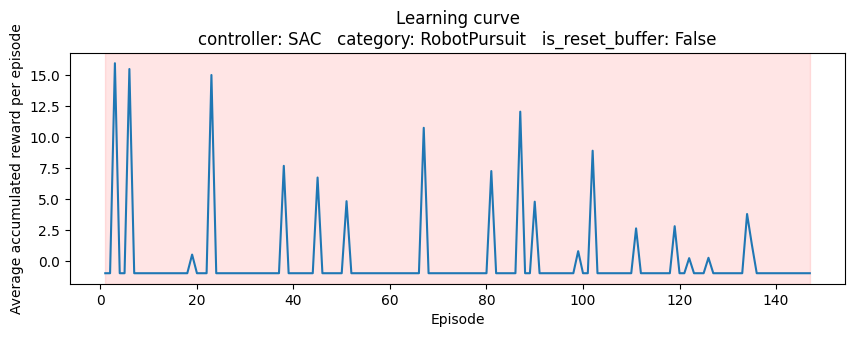

In [14]:
import matplotlib.pyplot as plt

def plot_learning_curve(index, index_names, df):
    fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value"]].groupby("iteration_id")
    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "mean", 
        "task_name": "last",
        "step_id": "last"
        })
    tmp_group_df.plot(y="current_undiscounted_value", ax=ax)

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.1, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Average accumulated reward per episode')
    ax.set_title(
        'Learning curve\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()


plot_learning_curve(group_df.index[0], group_df.index.names, df)
# plot_learning_curve(group_df.index[1], group_df.index.names, df)
# plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
# plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)

In [228]:
df

index   time  running_objective  \
controller category     is_reset_buffer                                    
SAC        RobotPursuit False                0  0.000               -1.0   
                        False                0  0.000               -1.0   
                        False                0  0.000               -1.0   
                        False                0  0.000               -1.0   
                        False                0  0.000               -1.0   
...                                        ...    ...                ...   
                        True                39  6.369               -1.0   
                        True                 0  0.000               -1.0   
                        True                 0  0.000               -1.0   
                        True                 0  0.000               -1.0   
                        True                 0  0.000               -1.0   

                                        current_value  \
controller category     is_reset_buffer                 
SAC        RobotPursuit False                    None   
                        False                    None   
                        False                    None   
                        False                    None   
                        False                    None   
...                                               ...   
                        True                     None   
                        True                     None   
                        True                     None   
                        True                     None   
                        True                     None   

                                         current_undiscounted_value  \
controller category     is_reset_buffer                               
SAC        RobotPursuit False                             -1.000000   
                        False                             -1.000000   
                        False                             -1.000000   
                        False                             -1.000000   
                        False                             -1.000000   
...                                                             ...   
                        True                              17.191722   
                        True                              -1.000000   
                        True                              -1.000000   
                        True                              -1.000000   
                        True                              -1.000000   

                                         episode_id  iteration_id task_name  \
controller category     is_reset_buffer                                       
SAC        RobotPursuit False                     1             1  red_cube   
                        False                     1             2  red_cube   
                        False                     1             3  red_cube   
                        False                     1             4  red_cube   
                        False                     1             5  red_cube   
...                                             ...           ...       ...   
                        True                      1           509  red_cube   
                        True                      1           510  red_cube   
                        True                      1           511  red_cube   
                        True                      1           512  red_cube   
                        True                      1           513  red_cube   

                                         step_id  Linear Velocity [m/s]  ...  \
controller category     is_reset_buffer                                  ...   
SAC        RobotPursuit False                  0               0.475357  ...   
                        False                  1               0.078009  ...   
                        False         

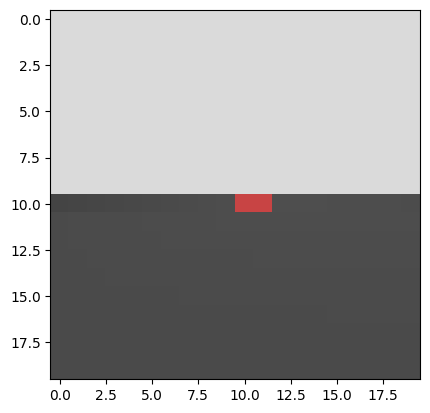

In [32]:
# df = df.reset_index()
pixel_columns = [c for c in df.columns if "pixel" in c.lower()]
chosen_state = np.array(df.loc[:, pixel_columns].iloc[-1])
im = chosen_state.reshape((20, 20, 3))

plt.imshow(im)

In [34]:
from src.objective import RobotPursuitRunningObjective

objective_func = RobotPursuitRunningObjective()

objective_func(state=im, 
               catcher_pos=[1, 1], 
               runner_pos=[0, 0], 
               action=[1, 0], 
               step_count=0, 
               max_steps_per_episode=100,
               runner_collision_thickness=0.49,
               arena_bounds=[-2.5,2.5,-2.5,2.5],
               info={})

COND: LOST


(-1.0, True, False)

In [18]:
import numpy as np
np.sum(im)

771.17645

KeyError: ('SAC', 'LineFollowing', False)

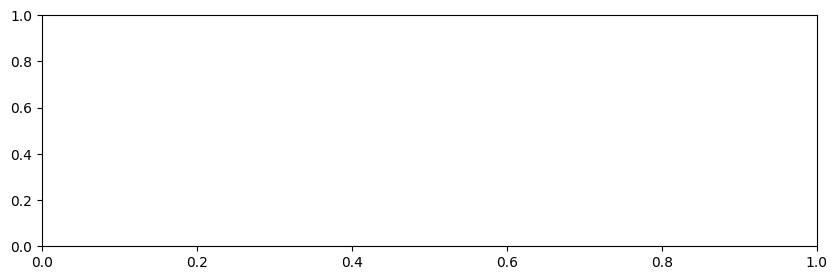

In [16]:
plot_learning_curve(('SAC', 'LineFollowing', False), group_df.index.names, df)
plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)

In [15]:
tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]
tmp_df[(tmp_df.step_id.diff() < 0)]
# tmp_df.step_id.values.tolist()[1:]+ [tmp_df.step_id.values.tolist()[-1]]

/tmp/ipykernel_127043/3476527340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]


index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                6  0.000           0.408163   
                         False                8  0.198           0.000000   
                         False                9  0.363           0.000000   
                         False               10  0.528           0.000000   
                         False               11  0.693           0.000000   
                         False                2  0.000           0.693878   
                         False               15  0.000           0.734694   
                         False               18  0.363           0.979592   
                         False               19  0.528           0.979592   
                         False               20  0.693           0.897959   
                         False               21  0.858           0.775510   
                         False               22  1.023           0.530612   
                         False               23  1.188           0.285714   
                         False               24  1.353           0.081633   
                         False               25  1.518           0.040816   
                         False               26  1.683          -1.000000   
                         False                0  0.000           0.530612   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer                               
SAC        LineFollowing False                              2.693878   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.122449   
                         False                              5.755102   
                         False                              8.448980   
                         False                              9.428571   
                         False                             10.326531   
                         False                             11.102041   
                         False                             11.632653   
                         False                             11.918367   
                         False                             12.000000   
                         False                             12.040816   
                         False                             11.040816   
                         False                              0.530612   

                                          episode_id  iteration_id  \
controller category      is_reset_bu

In [16]:
tmp_df[tmp_df.iteration_id == 1196]

index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                0  0.000           0.693878   
                         False                1  0.000           0.857143   
                         False               15  0.000           0.734694   
                         False               16  0.000           0.775510   
                         False               17  0.165           0.938776   
                         False                2  0.198           0.979592   
                         False                3  0.363           0.775510   
                         False               18  0.363           0.979592   
                         False                4  0.528           0.408163   
                         False               19  0.528           0.979592   
                         False                5  0.693           0.448980   
                         False               20  0.693           0.897959   
                         False                6  0.858           0.326531   
                         False               21  0.858           0.775510   
                         False                7  1.023           0.122449   
                         False               22  1.023           0.530612   
                         False                8  1.188           0.040816   
                         False               23  1.188           0.285714   
                         False                9  1.353           0.040816   
                         False               24  1.353           0.081633   
                         False               10  1.518           0.040816   
                         False               25  1.518           0.040816   
                         False               11  1.683           0.000000   
                         False               26  1.683          -1.000000   
                         False               12  1.848           0.081633   
                         False               13  2.013           0.081633   
                         False               14  2.178           0.122449   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer             